✅ Library Keuangan Siap!
✅ Data Keuangan Berhasil Dimuat dari: /kaggle/input/datasets/dwifarhan/income-statement/income_statement_clean.csv
   Jumlah Perusahaan/Data : 4
   Jumlah Metrik (Kolom)  : 19



,perusahaan,periode,pendapatan_jasa,penjualan_bersih,hpp,laba_kotor,total_beban_operasional,laba_dari_operasi,beban_bunga,laba_sebelum_pajak,pajak,laba_bersih,total_aset,total_liabilitas,total_ekuitas,gross_margin_pct,net_margin_pct,debt_ratio_pct,equity_ratio_pct
0,Kantor Konsultan Wirausaha,Des 2015,192000000,192000000,0,192000000,46500000,145500000,0,145500000,0,145500000,254000000,38500000,215500000,100.0,75.8,15.2,84.8
1,Perusahaan Dagang Latihan I,2015,0,4062000,2665000,1397000,1127000,510000,176000,334000,83500,205500,0,0,0,34.4,5.1,0.0,0.0
2,PT SEKAR,Des 2019,0,323000000,179900000,143100000,117200000,27800000,3700000,24100000,6025000,19050000,0,0,0,44.3,5.9,0.0,0.0
3,PT ABC,2020,0,0,0,0,0,0,0,-5000,0,-5000,98000,43000,55000,0.0,-5.1,43.9,56.1


=== 📊 RINGKASAN EKSEKUTIF KEUANGAN ===
1️⃣ Total Entitas Perusahaan : 4 Perusahaan
2️⃣ Laba Bersih Tertinggi    : Kantor Konsultan Wirausaha (Des 2015) -> Rp 145,500,000
3️⃣ Rata-rata Net Margin     : 20.4%
4️⃣ Debt Ratio Tertinggi     : PT ABC -> 43.9%
----------------------------------------


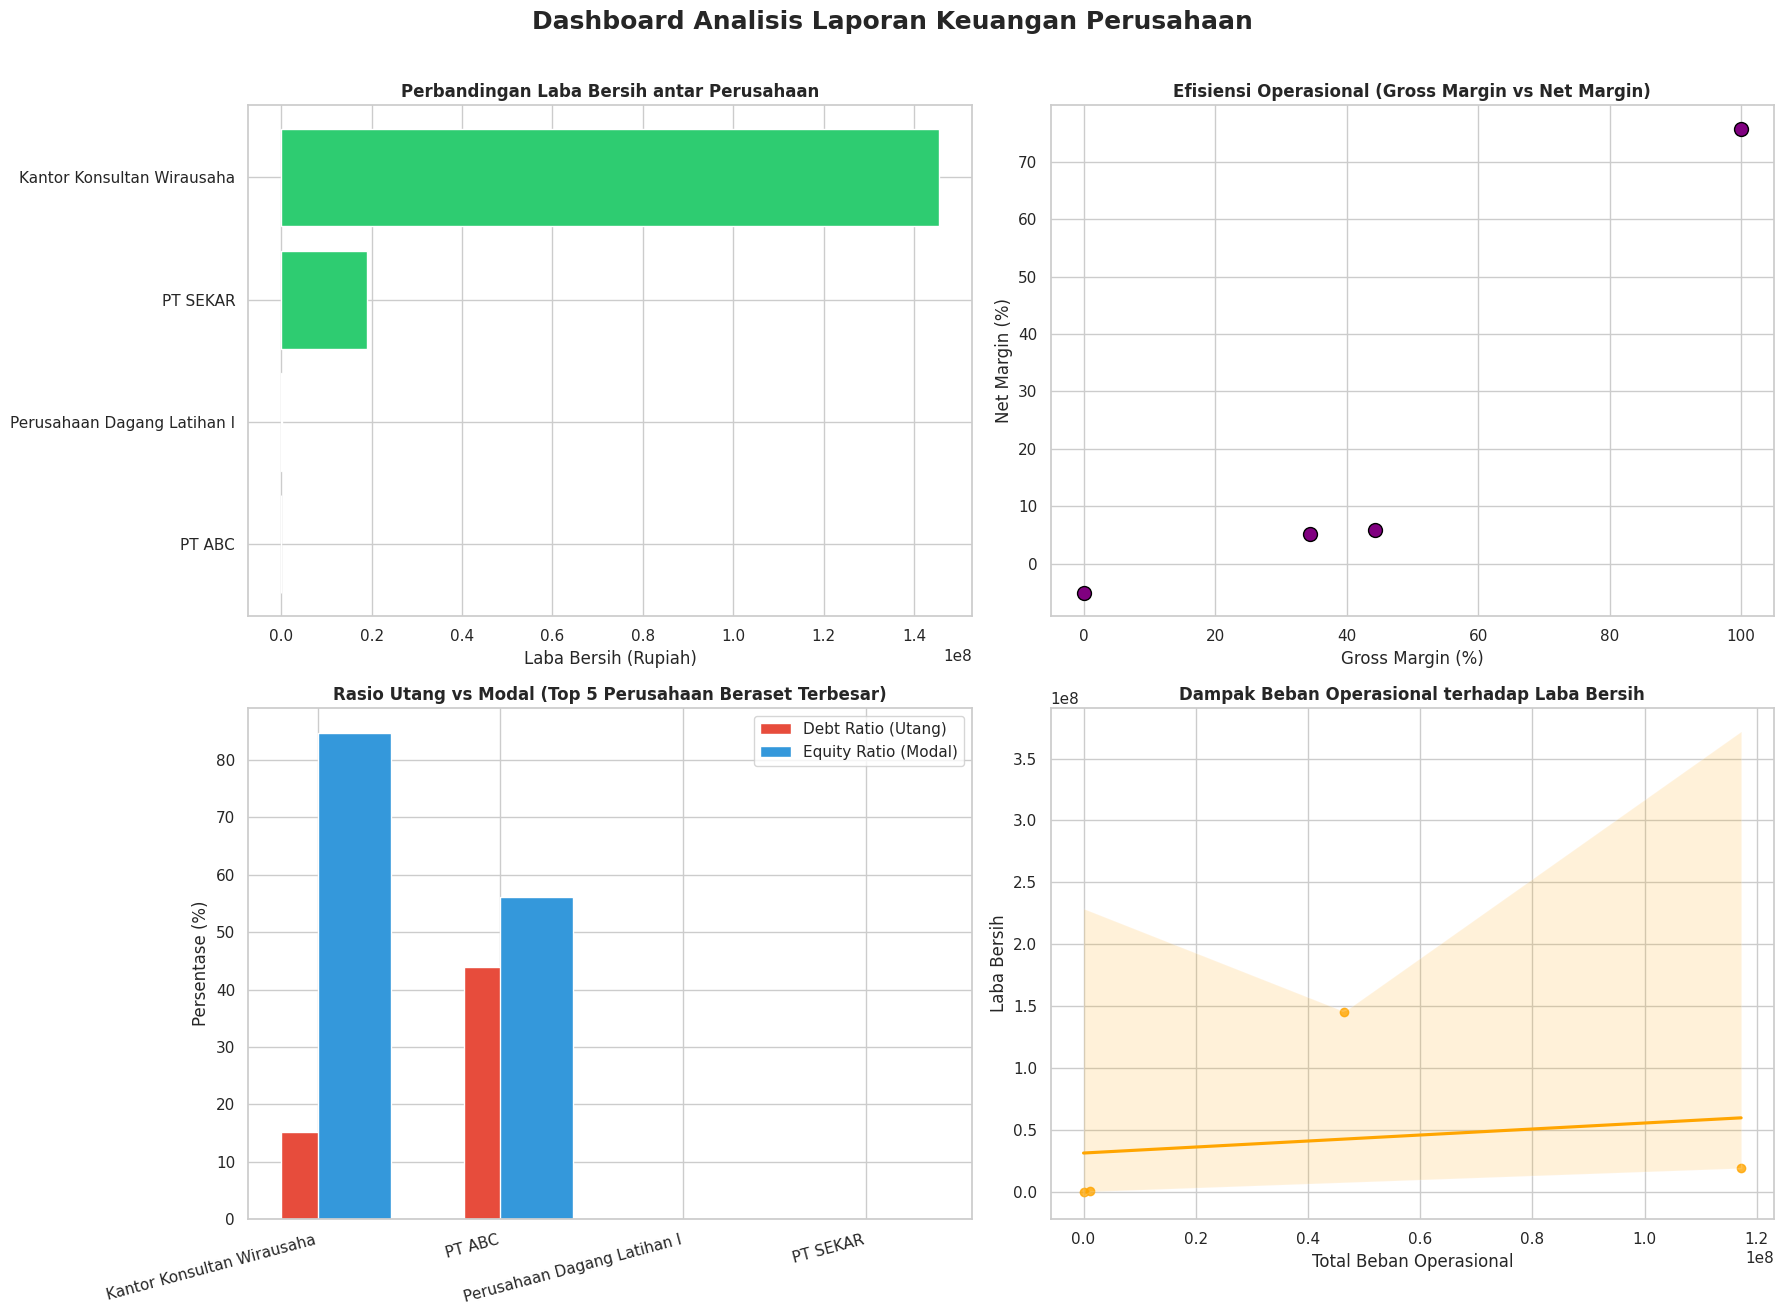

✅ Dashboard sukses digambar dan disimpan sebagai 'dashboard_keuangan.png'


In [1]:
# ============================================
# CELL 1 — Install & Import Library
# ============================================
!pip install pandas matplotlib seaborn --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Library Keuangan Siap!")

# ============================================
# CELL 2 — Auto-Load Data (Kaggle & Colab Friendly)
# ============================================
nama_target = 'income_statement_clean.csv'
path_file = nama_target 

if not os.path.exists(path_file):
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if nama_target in filename:
                path_file = os.path.join(dirname, filename)
                break

try:
    df_finance = pd.read_csv(path_file)
    print(f"✅ Data Keuangan Berhasil Dimuat dari: {path_file}")
    print(f"   Jumlah Perusahaan/Data : {len(df_finance)}")
    print(f"   Jumlah Metrik (Kolom)  : {df_finance.shape[1]}\n")
    display(df_finance.head())
except Exception as e:
    print(f"❌ File '{nama_target}' tidak ditemukan. Pastikan sudah di-upload! Error: {e}")

# ============================================
# CELL 3 — Ringkasan Eksekutif (Financial Insights)
# ============================================
if 'df_finance' in locals():
    print("=== 📊 RINGKASAN EKSEKUTIF KEUANGAN ===")
    
    # 1. Total Perusahaan
    total_perusahaan = df_finance['perusahaan'].nunique()
    print(f"1️⃣ Total Entitas Perusahaan : {total_perusahaan} Perusahaan")
    
    # 2. Perusahaan dengan Laba Bersih Tertinggi
    top_laba = df_finance.loc[df_finance['laba_bersih'].idxmax()]
    print(f"2️⃣ Laba Bersih Tertinggi    : {top_laba['perusahaan']} ({top_laba['periode']}) -> Rp {int(top_laba['laba_bersih']):,}")
    
    # 3. Rata-rata Profitabilitas (Net Margin)
    rata_net_margin = df_finance['net_margin_pct'].mean()
    print(f"3️⃣ Rata-rata Net Margin     : {rata_net_margin:.1f}%")
    
    # 4. Deteksi Perusahaan dengan Risiko Utang Tertinggi (Debt Ratio)
    top_debt = df_finance.loc[df_finance['debt_ratio_pct'].idxmax()]
    print(f"4️⃣ Debt Ratio Tertinggi     : {top_debt['perusahaan']} -> {top_debt['debt_ratio_pct']:.1f}%")
    print("-" * 40)

# ============================================
# CELL 4 — Dashboard Performa Keuangan
# ============================================
if 'df_finance' in locals():
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 13))
    fig.suptitle('Dashboard Analisis Laporan Keuangan Perusahaan', fontsize=18, fontweight='bold', y=1.01)

    # Chart 1: Bar Chart Laba Bersih per Perusahaan
    df_sorted_laba = df_finance.sort_values('laba_bersih', ascending=True)
    axes[0,0].barh(df_sorted_laba['perusahaan'], df_sorted_laba['laba_bersih'], color='#2ecc71')
    axes[0,0].set_title('Perbandingan Laba Bersih antar Perusahaan', fontweight='bold')
    axes[0,0].set_xlabel('Laba Bersih (Rupiah)')

    # Chart 2: Korelasi Gross Margin vs Net Margin
    axes[0,1].scatter(df_finance['gross_margin_pct'], df_finance['net_margin_pct'], color='purple', s=100, edgecolors='black')
    axes[0,1].set_title('Efisiensi Operasional (Gross Margin vs Net Margin)', fontweight='bold')
    axes[0,1].set_xlabel('Gross Margin (%)')
    axes[0,1].set_ylabel('Net Margin (%)')

    # Chart 3: Struktur Pendanaan (Debt Ratio vs Equity Ratio) - Top 5 Perusahaan
    top5_asset = df_finance.nlargest(5, 'total_aset')
    x = range(len(top5_asset))
    axes[1,0].bar(x, top5_asset['debt_ratio_pct'], width=0.4, label='Debt Ratio (Utang)', color='#e74c3c', align='center')
    axes[1,0].bar(x, top5_asset['equity_ratio_pct'], width=0.4, label='Equity Ratio (Modal)', color='#3498db', align='edge')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(top5_asset['perusahaan'], rotation=15, ha='right')
    axes[1,0].set_title('Rasio Utang vs Modal (Top 5 Perusahaan Beraset Terbesar)', fontweight='bold')
    axes[1,0].set_ylabel('Persentase (%)')
    axes[1,0].legend()

    # Chart 4: Beban Operasional vs Laba Bersih
    sns.regplot(data=df_finance, x='total_beban_operasional', y='laba_bersih', ax=axes[1,1], color='orange')
    axes[1,1].set_title('Dampak Beban Operasional terhadap Laba Bersih', fontweight='bold')
    axes[1,1].set_xlabel('Total Beban Operasional')
    axes[1,1].set_ylabel('Laba Bersih')

    plt.tight_layout()
    plt.savefig('dashboard_keuangan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Dashboard sukses digambar dan disimpan sebagai 'dashboard_keuangan.png'")